<a href="https://colab.research.google.com/github/DL4CV-NPTEL/2026/blob/main/notebooks/Week%203/L03_Feedforward_and_Gradient_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📺 [Lecture video](https://www.youtube.com/watch?v=KuM8C6_XCTU) &nbsp;|&nbsp; 📄 [Slides](https://github.com/DL4CV-NPTEL/2026/blob/main/Slides/Week%203/NPTEL_Jul24_DL4CV_W03_P02.pdf)

In [1]:
# Week 3, Lecture 3: FFN and Backprop Part 1
from IPython.display import HTML, display

VIDEO_ID = "KuM8C6_XCTU"

# YouTube's official embed markup. The `allow` list delegates the permissions the
# player needs; Colab renders outputs inside a nested iframe and without that
# delegation the player aborts with "Error 153".
display(HTML(f"""
<iframe width="720" height="405"
        src="https://www.youtube.com/embed/{VIDEO_ID}"
        title="YouTube video player" frameborder="0"
        allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share"
        referrerpolicy="strict-origin-when-cross-origin"
        allowfullscreen></iframe>
<p><a href="https://www.youtube.com/watch?v={VIDEO_ID}" target="_blank">Watch on YouTube</a></p>
"""))

# Week 3, Lecture 3: Feedforward Networks and Gradient Descent

**NPTEL Deep Learning for Computer Vision** | Prof. Vineeth N Balasubramanian, IIT Hyderabad

Companion notebook for **§3.2 Feedforward Networks and Backpropagation**.

A feedforward network is just a composition of simple functions, and we train it by
gradient descent: repeatedly nudging every weight a little in the direction that
lowers the loss. This notebook builds both ideas from scratch, then connects them to
real training with PyTorch autograd.

**What you will learn**
- A feedforward network as a composition $y = f^{(3)}(f^{(2)}(f^{(1)}(x)))$, by hand and as `nn.Sequential`.
- Gradient descent from scratch on $f(x) = x^2$, and why we step along the negative gradient.
- The multivariate reason the negative gradient is the steepest descent direction.
- A gradient-descent trajectory on a 2D loss bowl.
- A tiny MLP trained with autograd gradients and a manual weight update.

Note on backpropagation: computing the gradient of the loss with respect to every
weight is done by the chain rule. The systematic procedure for that is
backpropagation, which is Lecture 4. Here we only motivate the need for those
gradients and let autograd compute them.

**How to run**  This notebook runs on Colab (CPU or GPU) or local Jupyter.
Everything is tiny and finishes in seconds on CPU. Run the setup cell first.

**Contents**

1. A feedforward network is a composition of functions
2. Gradient descent from scratch (1D)
3. Why the negative gradient?
4. Gradient descent trajectory in 2D
5. Bridge to real training (autograd + manual update)

## Review

The previous lecture showed that a hidden layer makes XOR separable, and introduced smooth activation functions and the Universal Approximation Theorem. Those weights were set by hand. This lecture asks how to *learn* them, by composing layers into a feedforward network and descending its loss.

## Setup

In [2]:
# Run this cell first. Works on Colab (CPU or GPU) and local Jupyter.
import sys, subprocess
# ipywidgets ships with Colab; install only if it is missing.
try:
    import ipywidgets  # noqa: F401
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ipywidgets"])

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from ipywidgets import interact, interactive, FloatSlider, IntSlider, Dropdown, Checkbox, fixed
%matplotlib inline

# Reproducibility
torch.manual_seed(0)
np.random.seed(0)

# Use a GPU if one is available, otherwise CPU. Every demo here is tiny and
# runs in seconds on CPU, so no GPU is required.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.axisbelow"] = True

print("PyTorch", torch.__version__, "| device:", device)

PyTorch 2.8.0 | device: cpu


## 1. A feedforward network is a composition of functions

From the slides:
- A feedforward network (a multi-layer perceptron) is a set of neurons organized in layers.
- The neurons form a directed acyclic graph: information flows one way, from input $x$ to output $y$. Hence "feedforward".
- Each neuron is a vector-to-scalar function: it takes the previous layer's vector and returns one number.
- The whole network is a composition $y = f^{(3)}(f^{(2)}(f^{(1)}(x)))$, where $f^{(1)}$ is the first hidden layer, $f^{(2)}$ the second, and $f^{(3)}$ the output layer.
- Depth is the number of layers excluding the input layer.

We first build three layers by hand with explicit weight tensors and run the
forward pass one layer at a time, then rebuild the same function as
`nn.Sequential` and check the outputs match.

In [3]:
# A feedforward net is just function composition.
# Build three tiny layers with explicit weight/bias tensors (no nn.Module yet).
torch.manual_seed(3)

# Layer sizes: input=3 -> hidden1=4 -> hidden2=4 -> output=2  (depth = 3).
W1 = torch.randn(4, 3, device=device); b1 = torch.randn(4, device=device)
W2 = torch.randn(4, 4, device=device); b2 = torch.randn(4, device=device)
W3 = torch.randn(2, 4, device=device); b3 = torch.randn(2, device=device)

x = torch.tensor([1.0, -2.0, 0.5], device=device)   # one input vector

# Each layer is an affine map W a + b followed by an activation.
# One output number per neuron, so each neuron is a vector-to-scalar function.
def f1(v): return torch.tanh(W1 @ v + b1)   # first hidden layer
def f2(v): return torch.tanh(W2 @ v + b2)   # second hidden layer
def f3(v): return W3 @ v + b3               # output layer (identity activation)

a1 = f1(x)          # activations of hidden layer 1
a2 = f2(a1)         # activations of hidden layer 2
y  = f3(a2)         # network output  y = f3(f2(f1(x)))

print("input x     :", x.cpu().numpy())
print("a1 = f1(x)  :", a1.detach().cpu().numpy())
print("a2 = f2(a1) :", a2.detach().cpu().numpy())
print("y  = f3(a2) :", y.detach().cpu().numpy())
print("depth (weight layers, excluding input):", 3)

input x     : [ 1.  -2.   0.5]
a1 = f1(x)  : [-0.35095918 -0.79733455 -0.9628145   0.44016537]
a2 = f2(a1) : [ 0.45984754 -0.5386993  -0.7723965   0.49751768]
y  = f3(a2) : [-0.13469404  0.90983063]
depth (weight layers, excluding input): 3


manual      y : [-0.13469404  0.90983063]
nn.Sequential : [-0.13469404  0.90983063]
outputs match : True


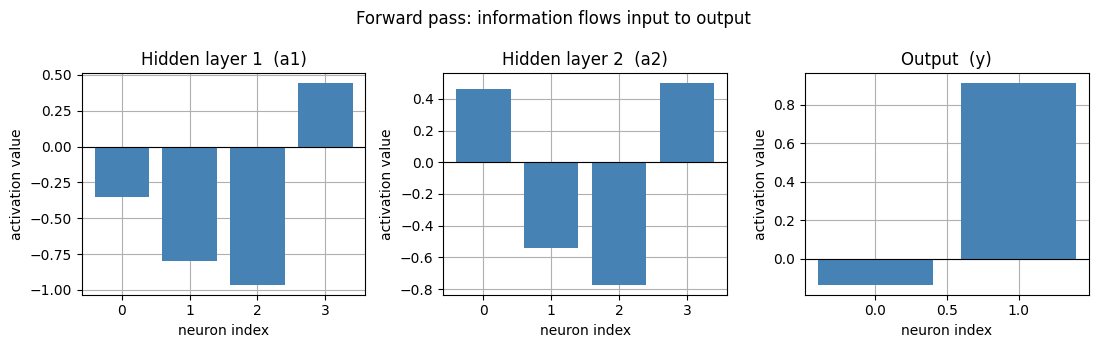

In [4]:
# The same computation, written the idiomatic PyTorch way as a stack of layers.
net = nn.Sequential(
    nn.Linear(3, 4), nn.Tanh(),   # f1
    nn.Linear(4, 4), nn.Tanh(),   # f2
    nn.Linear(4, 2),              # f3 (identity output)
).to(device)

# Copy our explicit tensors into the Sequential so both compute the SAME function.
with torch.no_grad():
    net[0].weight.copy_(W1); net[0].bias.copy_(b1)
    net[2].weight.copy_(W2); net[2].bias.copy_(b2)
    net[4].weight.copy_(W3); net[4].bias.copy_(b3)

y_seq = net(x)
print("manual      y :", y.detach().cpu().numpy())
print("nn.Sequential :", y_seq.detach().cpu().numpy())
print("outputs match :", bool(torch.allclose(y, y_seq, atol=1e-6)))

# Visualize the activations flowing forward through the network (left to right).
acts   = [a1.detach().cpu().numpy(), a2.detach().cpu().numpy(), y.detach().cpu().numpy()]
titles = ["Hidden layer 1  (a1)", "Hidden layer 2  (a2)", "Output  (y)"]
fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
for ax, a, t in zip(axes, acts, titles):
    ax.bar(range(len(a)), a, color="steelblue")
    ax.axhline(0, color="k", lw=0.8)
    ax.set_xlabel("neuron index"); ax.set_ylabel("activation value")
    ax.set_title(t)
fig.suptitle("Forward pass: information flows input to output")
plt.tight_layout(); plt.show()

A network is just function composition. Training searches for the weights inside
these functions. Next we learn how: gradient descent.

## 2. Gradient descent from scratch (1D)

We train networks by minimizing a loss such as mean squared error:
$$\text{Loss}_{MSE} = \frac{1}{M} \sum_{i=1}^{M} \big(f^{*}(x_i) - f(x_i; \theta)\big)^2 .$$

To build intuition, minimize a simple 1D function $f(x) = x^2$. We want
$x^{*} = \arg\min_x f(x)$.

- The derivative $f'(x) = 2x$ is the slope at $x$.
- A tiny step in the direction (sign) of the slope increases $f$:
  $f\big(x + p\,\text{sign}(f'(x))\big) > f(x)$ for an infinitesimally small $p$.
- So a tiny step in the opposite direction decreases $f$. That opposite direction is the negative gradient.

Gradient descent: start at a random $x$, then repeat
$$x \leftarrow x - \eta\, f'(x),$$
where $\eta$ is the learning rate. Small $\eta$ converges smoothly, $\eta$ near 1
oscillates, and $\eta > 1$ diverges.

step  0:  x =  4.0000   f(x) =  16.0000   f'(x) =  8.0000
step  1:  x =  3.2000   f(x) =  10.2400   f'(x) =  6.4000
step  2:  x =  2.5600   f(x) =  6.5536   f'(x) =  5.1200
step  3:  x =  2.0480   f(x) =  4.1943   f'(x) =  4.0960
step  4:  x =  1.6384   f(x) =  2.6844   f'(x) =  3.2768
step  5:  x =  1.3107   f(x) =  1.7180   f'(x) =  2.6214
...
final :  x =  0.1407   f(x) =  1.9807e-02


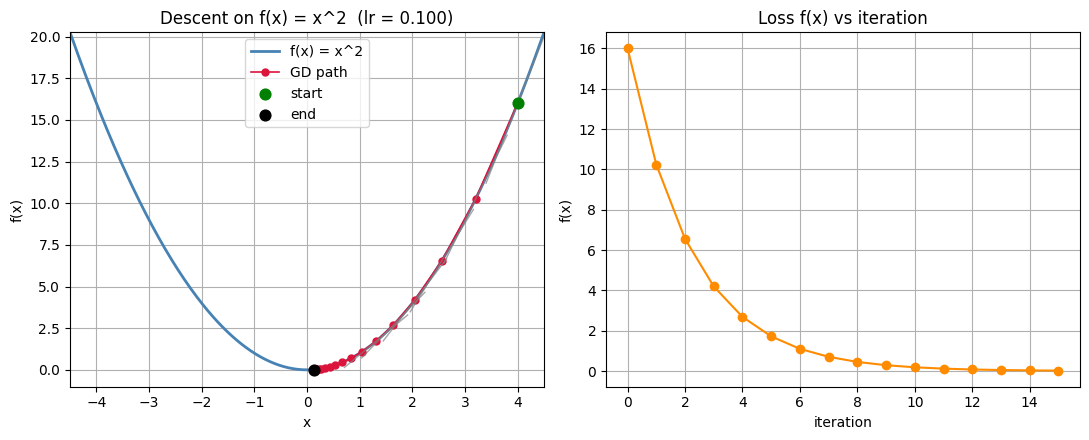

In [5]:
# f(x) = x^2 and its exact derivative f'(x) = 2x (the slope).
def f(x):      return x**2
def grad_f(x): return 2.0 * x

def run_gd_1d(x0, lr, steps):
    """Gradient descent from scratch: x <- x - lr * f'(x). Returns the path of x values."""
    xs = [float(x0)]
    x = float(x0)
    for _ in range(steps):
        x = x - lr * grad_f(x)      # step in the NEGATIVE gradient direction
        xs.append(x)
    return np.array(xs)

def plot_gd_1d(xs, lr):
    xs = np.asarray(xs, dtype=float)
    fx = xs**2
    finite = np.isfinite(xs)
    w = max(np.abs(xs[finite]).max() if finite.any() else 1.0, abs(xs[0]))
    w = min(w, 6.0) + 0.5           # cap the viewing window for readability

    grid = np.linspace(-w, w, 300)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

    # Left: the parabola, the descent path, and tangent lines at the first few points.
    ax1.plot(grid, grid**2, color="steelblue", lw=2, label="f(x) = x^2")
    ax1.plot(xs, fx, "o-", color="crimson", ms=5, lw=1.2, label="GD path")
    for i in range(min(len(xs) - 1, 6)):
        x0 = xs[i]
        if not np.isfinite(x0):
            continue
        seg = np.linspace(x0 - 0.6, x0 + 0.6, 2)
        ax1.plot(seg, x0**2 + 2*x0*(seg - x0), color="gray", lw=1.0, alpha=0.7)
    ax1.scatter([xs[0]], [xs[0]**2], color="green", zorder=5, s=60, label="start")
    if np.isfinite(xs[-1]):
        ax1.scatter([xs[-1]], [xs[-1]**2], color="black", zorder=5, s=60, label="end")
    ax1.set_xlim(-w, w); ax1.set_ylim(-0.05*w*w, w*w)
    ax1.set_xlabel("x"); ax1.set_ylabel("f(x)")
    ax1.set_title("Descent on f(x) = x^2  (lr = %.3f)" % lr)
    ax1.legend(loc="upper center")

    # Right: loss vs iteration.
    ax2.plot(np.arange(len(fx)), fx, "o-", color="darkorange")
    ax2.set_xlabel("iteration"); ax2.set_ylabel("f(x)")
    ax2.set_title("Loss f(x) vs iteration")
    if np.isfinite(fx).any() and np.nanmax(fx) > 1e3:
        ax2.set_yscale("log")
    plt.tight_layout(); plt.show()

# One run at a small learning rate, printing the first few steps.
path = run_gd_1d(x0=4.0, lr=0.1, steps=15)
for i in range(6):
    print("step %2d:  x = % .4f   f(x) = % .4f   f'(x) = % .4f" % (i, path[i], path[i]**2, 2*path[i]))
print("...")
print("final :  x = % .4f   f(x) = % .4e" % (path[-1], path[-1]**2))
plot_gd_1d(path, lr=0.1)

### Interactive: learning rate, start point, number of steps

Move the sliders. Look for smooth convergence at small `lr`, oscillation near
`lr = 1`, and divergence for `lr` above 1.

In [6]:
def gd1d_demo(lr=0.1, x0=4.0, steps=15):
    xs = run_gd_1d(x0, lr, steps)
    plot_gd_1d(xs, lr)

interact(gd1d_demo,
         lr=FloatSlider(min=0.01, max=1.5, step=0.01, value=0.1, description="lr"),
         x0=FloatSlider(min=-5.0, max=5.0, step=0.1, value=4.0, description="start x"),
         steps=IntSlider(min=1, max=40, step=1, value=15, description="steps"));

interactive(children=(FloatSlider(value=0.1, description='lr', max=1.5, min=0.01, step=0.01), FloatSlider(valu…

## 3. Why the negative gradient?

For a real network the loss $L(\theta)$ depends on many weights $\theta$. Consider a
unit direction $u$ (so $u^T u = 1$). The rate of change of $L$ along $u$ is the
directional derivative $u^T \nabla_\theta L$. The direction that decreases $L$ the
fastest solves
$$\min_{u,\; u^T u = 1} \; u^T \nabla_\theta L \;=\; \min_{u} \|u\|_2 \, \|\nabla_\theta L\|_2 \cos\beta \;=\; \|\nabla_\theta L\|_2 \cos\beta .$$

Since $\|u\|_2 = 1$, this is smallest (most negative) when $\cos\beta = -1$, that is
$\beta = 180^{\circ}$: when $u$ points opposite the gradient. So the negative gradient
is the direction of steepest descent.

Below: a 2D bowl $L(a, b) = a^2 + 3b^2$, its gradient at a point, and the directional
derivative $u^T \nabla L$ as $u$ rotates. It bottoms out exactly opposite the gradient.

point p       : [2.5 1.5]
gradient at p : [5. 9.]  with norm 10.296


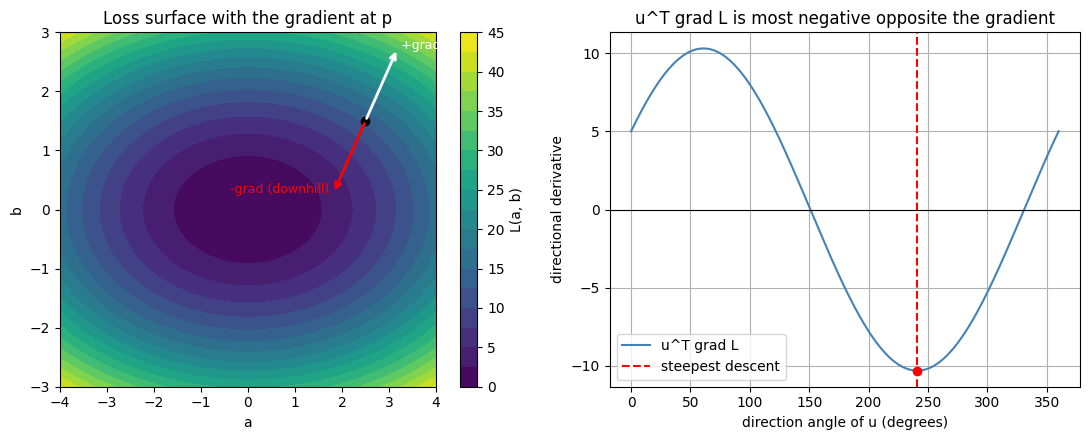

In [7]:
# A 2D "bowl" loss L(a, b) = a^2 + 3 b^2 and its exact gradient (2a, 6b).
def L_bowl(a, b):    return a**2 + 3.0*b**2
def grad_bowl(a, b): return np.array([2.0*a, 6.0*b])

# Grid for filled contours.
A, B = np.meshgrid(np.linspace(-4, 4, 300), np.linspace(-3, 3, 300))
Z = L_bowl(A, B)

# Pick a point and read off the gradient there.
p = np.array([2.5, 1.5])
g = grad_bowl(p[0], p[1])
gnorm = float(np.linalg.norm(g))
print("point p       :", p)
print("gradient at p :", g, " with norm", round(gnorm, 3))

# Directional derivative u^T g for every unit direction u(theta).
thetas = np.linspace(0, 2*np.pi, 361)
dderiv = g[0]*np.cos(thetas) + g[1]*np.sin(thetas)   # = gnorm * cos(theta - angle(g))
theta_min = thetas[int(np.argmin(dderiv))]           # steepest descent direction

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

# Left: contours with the +gradient (uphill) and -gradient (downhill) arrows.
cs = ax1.contourf(A, B, Z, levels=20, cmap="viridis")
fig.colorbar(cs, ax=ax1, label="L(a, b)")
ax1.grid(False)
arr = 1.4 / gnorm
ax1.annotate("", xy=(p[0]+g[0]*arr, p[1]+g[1]*arr), xytext=(p[0], p[1]),
             arrowprops=dict(arrowstyle="->", color="white", lw=2))
ax1.annotate("", xy=(p[0]-g[0]*arr, p[1]-g[1]*arr), xytext=(p[0], p[1]),
             arrowprops=dict(arrowstyle="->", color="red", lw=2))
ax1.text(p[0]+g[0]*arr, p[1]+g[1]*arr, " +grad (uphill)", color="white", fontsize=9)
ax1.text(p[0]-g[0]*arr, p[1]-g[1]*arr, "-grad (downhill) ", color="red",
         fontsize=9, ha="right")
ax1.plot(p[0], p[1], "ko", ms=6)
ax1.set_xlabel("a"); ax1.set_ylabel("b")
ax1.set_title("Loss surface with the gradient at p")

# Right: directional derivative vs the angle of the direction u.
ax2.plot(np.degrees(thetas), dderiv, color="steelblue", label="u^T grad L")
ax2.axhline(0, color="k", lw=0.8)
ax2.axvline(np.degrees(theta_min), color="red", ls="--", label="steepest descent")
ax2.scatter([np.degrees(theta_min)], [dderiv.min()], color="red", zorder=5)
ax2.set_xlabel("direction angle of u (degrees)"); ax2.set_ylabel("directional derivative")
ax2.set_title("u^T grad L is most negative opposite the gradient")
ax2.legend()
plt.tight_layout(); plt.show()

### Interactive: rotate the direction u

Rotate $u$ and read off $u^T \nabla L$. It is most negative when $u$ is opposite the
gradient (the red steepest-descent marker on the right).

In [8]:
desc_angle = float(np.degrees(theta_min) % 360)   # default: the steepest-descent direction

def dirderiv_demo(angle_deg=desc_angle):
    th = np.deg2rad(angle_deg)
    u = np.array([np.cos(th), np.sin(th)])
    dd = float(g @ u)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
    cs = ax1.contourf(A, B, Z, levels=20, cmap="viridis")
    fig.colorbar(cs, ax=ax1, label="L(a, b)")
    ax1.grid(False)
    arr = 1.4 / gnorm
    ax1.annotate("", xy=(p[0]-g[0]*arr, p[1]-g[1]*arr), xytext=(p[0], p[1]),
                 arrowprops=dict(arrowstyle="->", color="red", lw=1.5))     # -grad
    ax1.annotate("", xy=(p[0]+u[0]*1.4, p[1]+u[1]*1.4), xytext=(p[0], p[1]),
                 arrowprops=dict(arrowstyle="->", color="yellow", lw=2.5))  # chosen u
    ax1.plot(p[0], p[1], "ko", ms=6)
    ax1.set_xlabel("a"); ax1.set_ylabel("b")
    ax1.set_title("u at %.0f deg,  u^T grad = %.2f" % (angle_deg, dd))

    ax2.plot(np.degrees(thetas), dderiv, color="steelblue")
    ax2.axhline(0, color="k", lw=0.8)
    ax2.axvline(angle_deg, color="orange", lw=2, label="current u")
    ax2.scatter([angle_deg], [dd], color="orange", zorder=5, s=60)
    ax2.scatter([np.degrees(theta_min)], [dderiv.min()], color="red", zorder=5,
                label="most negative")
    ax2.set_xlabel("direction angle of u (degrees)"); ax2.set_ylabel("u^T grad L")
    ax2.set_title("Directional derivative for the chosen u")
    ax2.legend()
    plt.tight_layout(); plt.show()

interact(dirderiv_demo,
         angle_deg=FloatSlider(min=0, max=360, step=5, value=desc_angle,
                               description="u angle"));

interactive(children=(FloatSlider(value=241.00000000000003, description='u angle', max=360.0, step=5.0), Outpu…

## 4. Gradient descent trajectory in 2D

Now run the update on the bowl itself. With $\theta = (a, b)$ and
$\nabla L = (2a,\; 6b)$, repeat
$$\theta \leftarrow \theta - \eta\, \nabla L(\theta).$$

The path walks downhill toward the minimum at the origin. Because the bowl is steeper
in $b$ than in $a$, a large learning rate makes $b$ overshoot and zig-zag, or even
diverge, while a small one converges slowly.

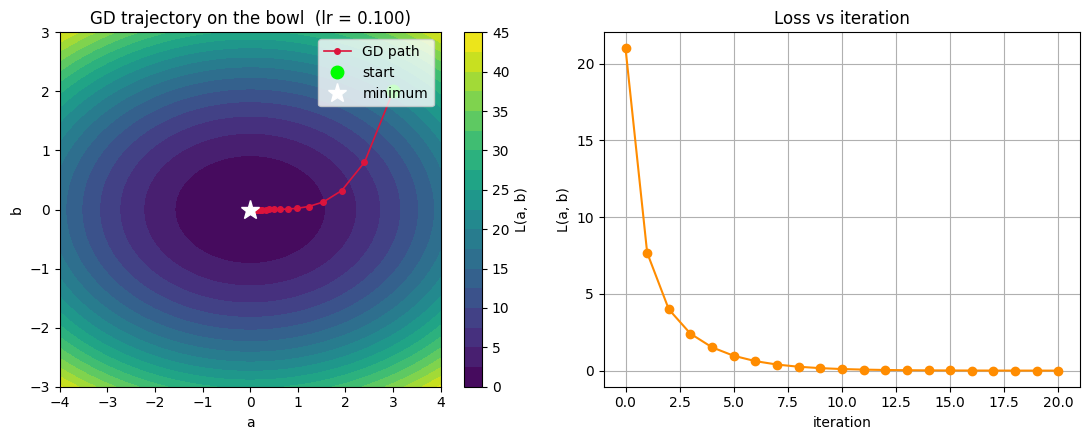

In [9]:
def run_gd_2d(start, lr, steps):
    """Gradient descent on the 2D bowl: theta <- theta - lr * grad L(theta)."""
    t = np.array(start, dtype=float)
    path = [t.copy()]
    for _ in range(steps):
        t = t - lr * grad_bowl(t[0], t[1])
        path.append(t.copy())
    return np.array(path)

def plot_gd_2d(path, lr):
    path = np.asarray(path, dtype=float)
    loss = L_bowl(path[:, 0], path[:, 1])
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

    cs = ax1.contourf(A, B, Z, levels=20, cmap="viridis")
    fig.colorbar(cs, ax=ax1, label="L(a, b)")
    ax1.grid(False)
    ax1.plot(path[:, 0], path[:, 1], "o-", color="crimson", ms=4, lw=1.2, label="GD path")
    ax1.plot(path[0, 0], path[0, 1], "o", color="lime", ms=9, label="start")
    ax1.plot(0, 0, "*", color="white", ms=14, label="minimum")
    ax1.set_xlim(-4, 4); ax1.set_ylim(-3, 3)
    ax1.set_xlabel("a"); ax1.set_ylabel("b")
    ax1.set_title("GD trajectory on the bowl  (lr = %.3f)" % lr)
    ax1.legend(loc="upper right")

    ax2.plot(np.arange(len(loss)), loss, "o-", color="darkorange")
    ax2.set_xlabel("iteration"); ax2.set_ylabel("L(a, b)")
    ax2.set_title("Loss vs iteration")
    if np.isfinite(loss).any() and np.nanmax(loss) > 1e3:
        ax2.set_yscale("log")
    plt.tight_layout(); plt.show()

path2d = run_gd_2d(start=(3.0, 2.0), lr=0.1, steps=20)
plot_gd_2d(path2d, lr=0.1)

### Interactive: learning rate and steps on the 2D descent

Too small is slow, too big overshoots or diverges. Notice that the steeper $b$
direction blows up first.

In [10]:
def gd2d_demo(lr=0.1, steps=20):
    path = run_gd_2d(start=(3.0, 2.0), lr=lr, steps=steps)
    plot_gd_2d(path, lr)

interact(gd2d_demo,
         lr=FloatSlider(min=0.01, max=0.5, step=0.01, value=0.1, description="lr"),
         steps=IntSlider(min=1, max=40, step=1, value=20, description="steps"));

interactive(children=(FloatSlider(value=0.1, description='lr', max=0.5, min=0.01, step=0.01), IntSlider(value=…

## 5. Bridge to real training (autograd + manual update)

Putting it together (from the slide "How to use gradient descent"):
1. Start with random weights $\theta$.
2. Compute the loss $L(\theta)$ over the data (here, MSE).
3. Compute the gradient $\frac{\partial L}{\partial \theta_i}$ for every weight.
4. Update each weight $\theta_i \leftarrow \theta_i - \eta \frac{\partial L}{\partial \theta_i}$.
5. Repeat until the gradient is about zero.

Chain rule teaser: the gradient with respect to a weight in layer $i$ depends on all
the later layers (from $i+1$ up to the output) through the chain rule. Computing these
efficiently for every weight is exactly backpropagation, which is Lecture 4. Here we
let PyTorch autograd compute the gradients with `loss.backward()` and we do the update
by hand, so steps 2 to 4 are explicit:

```
loss.backward()                      # autograd fills p.grad for every weight
with torch.no_grad():
    for p in model.parameters():
        p -= lr * p.grad             # the gradient-descent step
        p.grad.zero_()               # reset for the next step
```

We fit a tiny MLP ($1 \to 16 \to 16 \to 1$), the same kind of composition as section 1,
to $y = \sin(2x)$.

initial loss = 0.4855   final loss = 0.1002


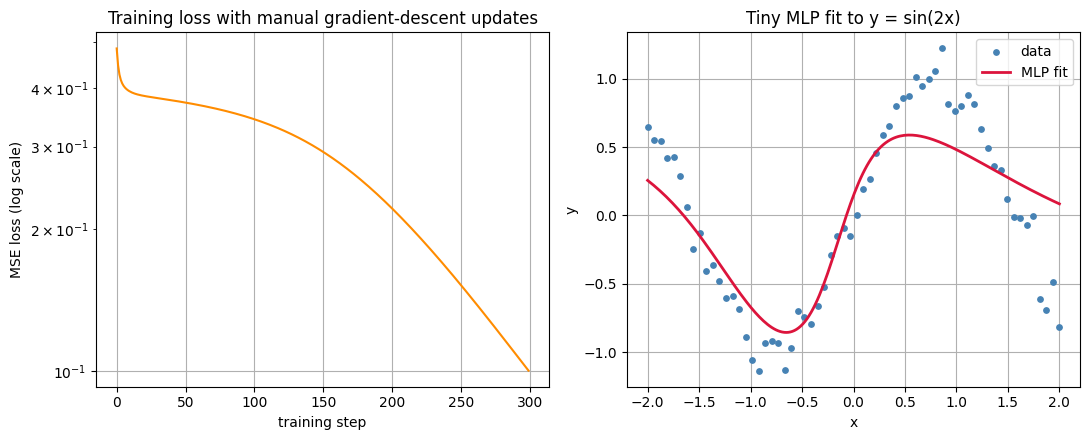

In [11]:
# A tiny 1D regression task: fit y = sin(2x) from a few noisy samples.
torch.manual_seed(0)
N = 64
Xtr = torch.linspace(-2.0, 2.0, N, device=device).unsqueeze(1)        # shape (N, 1)
Ytr = torch.sin(2.0 * Xtr) + 0.1 * torch.randn(N, 1, device=device)

def make_mlp():
    """A small MLP, built fresh and seeded so runs are reproducible."""
    torch.manual_seed(0)
    return nn.Sequential(
        nn.Linear(1, 16),  nn.Tanh(),
        nn.Linear(16, 16), nn.Tanh(),
        nn.Linear(16, 1),
    ).to(device)

# Train with autograd gradients and a MANUAL gradient-descent update.
model = make_mlp()
lr, steps = 0.05, 300
losses = []
for step in range(steps):
    pred = model(Xtr)
    loss = ((pred - Ytr) ** 2).mean()        # mean squared error (LossMSE from the slide)
    loss.backward()                          # autograd fills p.grad for every weight
    with torch.no_grad():
        for p in model.parameters():
            p -= lr * p.grad                 # gradient-descent step, done by hand
            p.grad.zero_()                   # reset before the next step
    losses.append(loss.item())

print("initial loss = %.4f   final loss = %.4f" % (losses[0], losses[-1]))

# The gradients came from autograd; Lecture 4 shows how backprop computes them.
xs_plot = torch.linspace(-2.0, 2.0, 200, device=device).unsqueeze(1)
with torch.no_grad():
    ys_plot = model(xs_plot).cpu().numpy().ravel()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
ax1.plot(np.arange(len(losses)), losses, color="darkorange")
ax1.set_yscale("log")
ax1.set_xlabel("training step"); ax1.set_ylabel("MSE loss (log scale)")
ax1.set_title("Training loss with manual gradient-descent updates")
ax2.scatter(Xtr.cpu().numpy().ravel(), Ytr.cpu().numpy().ravel(), s=15,
            color="steelblue", label="data")
ax2.plot(xs_plot.cpu().numpy().ravel(), ys_plot, color="crimson", lw=2, label="MLP fit")
ax2.set_xlabel("x"); ax2.set_ylabel("y")
ax2.set_title("Tiny MLP fit to y = sin(2x)")
ax2.legend()
plt.tight_layout(); plt.show()

### Interactive: learning rate and steps for the MLP

The same manual update, now on a real network. See how the learning rate controls how
fast (or whether) the loss drops.

In [12]:
def train_demo(lr=0.05, steps=300):
    model = make_mlp()
    ls = []
    for _ in range(steps):
        pred = model(Xtr)
        loss = ((pred - Ytr) ** 2).mean()
        loss.backward()
        with torch.no_grad():
            for p in model.parameters():
                p -= lr * p.grad
                p.grad.zero_()
        ls.append(loss.item())
    with torch.no_grad():
        yhat = model(xs_plot).cpu().numpy().ravel()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
    ax1.plot(np.arange(len(ls)), ls, color="darkorange")
    ax1.set_yscale("log")
    ax1.set_xlabel("training step"); ax1.set_ylabel("MSE loss (log scale)")
    ax1.set_title("Loss curve  (lr = %.3f)" % lr)
    ax2.scatter(Xtr.cpu().numpy().ravel(), Ytr.cpu().numpy().ravel(), s=15,
                color="steelblue", label="data")
    ax2.plot(xs_plot.cpu().numpy().ravel(), yhat, color="crimson", lw=2, label="MLP fit")
    ax2.set_xlabel("x"); ax2.set_ylabel("y")
    ax2.set_title("Fit after training"); ax2.legend()
    plt.tight_layout(); plt.show()

interact(train_demo,
         lr=FloatSlider(min=0.005, max=0.2, step=0.005, value=0.05, description="lr"),
         steps=IntSlider(min=20, max=400, step=20, value=300, description="steps"));

interactive(children=(FloatSlider(value=0.05, description='lr', max=0.2, min=0.005, step=0.005), IntSlider(val…

## Key takeaways

- A feedforward network is a composition of functions $y = f^{(3)}(f^{(2)}(f^{(1)}(x)))$; depth counts the layers after the input; each neuron maps a vector to a scalar.
- We fit the weights $\theta$ by minimizing a loss (for example MSE) with gradient descent.
- The derivative is the slope; stepping along the negative gradient decreases the loss. Update rule: $\theta \leftarrow \theta - \eta \nabla L(\theta)$.
- The negative gradient is the steepest-descent direction because $u^T \nabla L$ is most negative when $u$ points opposite the gradient.
- The learning rate $\eta$ matters: too small is slow, too large overshoots or diverges.
- Autograd gives us $\partial L / \partial \theta_i$ for every weight; the update itself is the same one-line gradient-descent step.

## Exercises
- Redo section 2 with autograd: set `x = torch.tensor([4.0], requires_grad=True)`, compute `loss = x**2`, call `loss.backward()`, and update `x` inside `torch.no_grad()`. Confirm the gradient equals $2x$.
- Work out $f'(x)$ for the sigmoid $\sigma(x) = 1/(1+e^{-x})$ and for $\tanh(x)$. You will need these derivatives for backpropagation in Lecture 4.